
# Parameter Extraction Evaluation

This notebook rigorously tests the AI orchestration system's parameter extraction capability. 
It evaluates whether the orchestrator can:
1. Correctly extract required parameters from natural language.
2. Infer missing parameters intelligently.
3. Handle ambiguous or incomplete inputs.
4. Respect schema constraints without hallucinating.


In [1]:

import pandas as pd
import json
import asyncio
from pprint import pprint
import matplotlib.pyplot as plt
import sys
import os

# Add backend directory to path
sys.path.insert(0, os.path.abspath('.'))

# Import actual orchestrator pipeline
from app.graph.workflow import run_orchestrator

def print_break():
    print("=" * 80)
    
print("✅ Libraries and Orchestrator imported successfully.")


✅ Libraries and Orchestrator imported successfully.



---
## 1. Tool Schemas
We define the ground-truth schemas for three primary tools utilized in this evaluation.


In [2]:

TOOL_SCHEMAS = {
    "flashcard_generator": {
        "required": ["topic"],
        "optional": {"count": 5, "difficulty": "medium", "subject": "general"},
        "enums": {"difficulty": ["easy", "medium", "hard"]}
    },
    "concept_explainer": {
        "required": ["concept_to_explain"],
        "optional": {"current_topic": "general", "desired_depth": "intermediate"},
        "enums": {"desired_depth": ["basic", "intermediate", "advanced", "comprehensive"]}
    },
    "quiz_me": {
        "required": ["topic"],
        "optional": {"difficulty": "medium", "count": 5},
        "enums": {"difficulty": ["easy", "medium", "hard"]}
    }
}
print("Schemas loaded.")


Schemas loaded.



---
## 2. Evaluation Dataset
Contains explicit inputs, implicit inputs (missing parameters requiring inference), and ambiguous requests.


In [3]:

EVAL_DATASET = [
    {
        "id": "exp_01",
        "input": "Make me 10 hard flashcards about cell division for biology.",
        "expected_tool": "flashcards",
        "expected_params": {"topic": "cell division", "count": 10, "difficulty": "hard", "subject": "biology"},
        "case_type": "explicit"
    },
    {
        "id": "exp_02",
        "input": "Explain quantum entanglement at an advanced level.",
        "expected_tool": "concept_explainer",
        "expected_params": {"concept_to_explain": "quantum entanglement", "desired_depth": "advanced"},
        "case_type": "explicit"
    },
    {
        "id": "imp_01",
        "input": "Make some flashcards about rivers.",
        "expected_tool": "flashcards",
        "expected_params": {"topic": "rivers"}, # Count & difficulty missing, should be inferred or defaulted
        "case_type": "implicit_missing_params"
    },
    {
        "id": "imp_02",
        "input": "I have an exam on WW2. Quiz me.",
        "expected_tool": "quiz_me",
        "expected_params": {"topic": "WW2"}, # Count & difficulty inferred
        "case_type": "implicit_missing_params"
    },
    {
        "id": "amb_01",
        "input": "Can you explain that?",
        "expected_tool": "clarification",
        "expected_params": {}, # Ambiguous input should trigger classification/fallback
        "case_type": "ambiguous"
    },
    {
        "id": "halluc_01",
        "input": "Make a quiz about gravity.",
        "expected_tool": "quiz_me",
        "expected_params": {"topic": "gravity"}, 
        "case_type": "check_hallucination" 
    }
]
print(f"Loaded {len(EVAL_DATASET)} parameter evaluation cases.")


Loaded 6 parameter evaluation cases.



---
## 3. Parameter Evaluation Logic
Strict algorithmic evaluation of required fields, extra fields (hallucinations), and correct inferred parameters.


In [4]:

def evaluate_params(expected_params: dict, predicted_params: dict, tool_name: str) -> dict:
    # If the tool doesn't match at all, params are irrelevant for accuracy
    if tool_name not in TOOL_SCHEMAS:
        return {
            "param_accuracy": 0.0, "missing_fields": list(expected_params.keys()),
            "extra_fields": [], "incorrect_values": [], "inference_score": 0.0,
            "handled_ambiguity_correctly": False
        }
        
    schema = TOOL_SCHEMAS[tool_name]
    
    missing_fields = []
    extra_fields = []
    incorrect_values = []
    
    total_fields_to_check = len(expected_params)
    fields_correct = 0
    
    # 1. Check Expected Params (Explicitly required by the test case)
    for key, exp_val in expected_params.items():
        if key not in predicted_params:
            missing_fields.append(key)
        else:
            # Check correctness (case insensitive for strings)
            pred_val = predicted_params[key]
            if isinstance(exp_val, str) and isinstance(pred_val, str):
                if exp_val.lower() in pred_val.lower() or pred_val.lower() in exp_val.lower():
                    fields_correct += 1
                else:
                    incorrect_values.append({key: f"Expected '{exp_val}', got '{pred_val}'"})
            elif exp_val == pred_val:
                fields_correct += 1
            else:
                incorrect_values.append({key: f"Expected '{exp_val}', got '{pred_val}'"})

    # 2. Check Extra Fields (Hallucinations)
    for key in predicted_params:
        if key not in expected_params and key not in schema["required"] and key not in schema["optional"]:
            extra_fields.append(key)
            
    # 3. Parameter Accuracy
    param_accuracy = fields_correct / total_fields_to_check if total_fields_to_check > 0 else 1.0
    
    # 4. Inference / Default Evaluation
    # If standard optional fields were applied dynamically when they weren't explicitly ordered
    inference_score = 0.0
    for key in predicted_params:
        if key in schema["optional"] and key not in expected_params:
            # Reward for correctly inferring default/valid optional parameters without breaking schema
            inference_score += 1.0

    return {
        "param_accuracy": round(param_accuracy, 2),
        "missing_fields": missing_fields,
        "extra_fields": extra_fields,
        "incorrect_values": incorrect_values,
        "inference_score": inference_score,
        "handled_ambiguity_correctly": None # Handled later
    }



---
## 4. Execution Pipeline
Runs the orchestrator to extract actual parameters, then evaluates them against expected outputs.


In [5]:

async def run_evaluation():
    results = []
    for test in EVAL_DATASET:
        print(f"Testing: {test['id']} | {test['input']}")
        
        # In a generic environment, we'll route to the test student
        state = await run_orchestrator(
            message=test["input"], 
            session_id=f"param_eval_{test['id']}", 
            student_id="student_eval"
        )
        
        predicted_tool = state.get("selected_tool", "")
        # fallback to inferred parameters if validation fails/clarification triggered
        predicted_params = state.get("validated_params") or state.get("inferred_params") or {}
        
        # Evaluate
        eval_metrics = evaluate_params(test["expected_params"], predicted_params, predicted_tool)
        
        # Check Ambiguity Handling
        if test["case_type"] == "ambiguous":
            handled = (predicted_tool == "clarification" or len(predicted_params) == 0)
            eval_metrics["handled_ambiguity_correctly"] = handled
            
        # Collect Row
        row = {
            "test_id": test["id"],
            "input": test["input"],
            "expected_tool": test["expected_tool"],
            "predicted_tool": predicted_tool,
            "expected_params": str(test["expected_params"]),
            "predicted_params": str(predicted_params),
            "case_type": test["case_type"],
            **eval_metrics
        }
        results.append(row)
        
    return pd.DataFrame(results)

# Run!
df_results = await run_evaluation()
display(df_results)


Testing: exp_01 | Make me 10 hard flashcards about cell division for biology.
2026-04-18 03:27:50,550 INFO {"stage": "Reasoner", "level": "INFO", "message": "short-circuit: intent=flashcards, conf=0.9", "data": {"source": "rule"}}
2026-04-18 03:27:50,554 INFO {"stage": "Tool Selector", "level": "INFO", "message": "selected=flashcards conf=0.63 (ranker=0.44, reasoning=0.90) via ranker; top3=['flashcards', 'mnemonic_generator', 'anchor_chart_maker']; dropped=0 schema-incompatible", "data": {"reason": "keywords ['flashcards', 'for']; intent match 'memorize'; +intent-match boost (+0.30)"}}
2026-04-18 03:27:51,624 INFO {"stage": "Extractor", "level": "INFO", "message": "extracted 4 explicit params for flashcards", "data": {"params": ["topic", "count", "difficulty", "subject"]}}
2026-04-18 03:27:51,626 INFO {"stage": "Personalization", "level": "INFO", "message": "plan: mastery L5, emotion=confused, style=direct → difficulty=easy, depth=basic, count=3", "data": {"reasons": ["mastery L5 → dif

,test_id,input,expected_tool,predicted_tool,expected_params,predicted_params,case_type,param_accuracy,missing_fields,extra_fields,incorrect_values,inference_score,handled_ambiguity_correctly
0,exp_01,Make me 10 hard flashcards about cell division...,flashcards,flashcards,"{'topic': 'cell division', 'count': 10, 'diffi...","{'topic': 'cell division', 'count': 10, 'diffi...",explicit,0.0,"[topic, count, difficulty, subject]",[],[],0.0,False
1,exp_02,Explain quantum entanglement at an advanced le...,concept_explainer,concept_explainer,"{'concept_to_explain': 'quantum entanglement',...","{'concept_to_explain': 'quantum entanglement',...",explicit,1.0,[],"[user_info, chat_history]",[],1.0,None
2,imp_01,Make some flashcards about rivers.,flashcards,flashcards,{'topic': 'rivers'},"{'topic': 'rivers', 'difficulty': 'medium', 'c...",implicit_missing_params,0.0,[topic],[],[],0.0,False
3,imp_02,I have an exam on WW2. Quiz me.,quiz_me,quiz_me,{'topic': 'WW2'},"{'topic': 'WW2', 'subject': 'history', 'diffic...",implicit_missing_params,1.0,[],"[subject, num_questions, question_type, time_p...",[],1.0,None
4,amb_01,Can you explain that?,clarification,concept_explainer,{},"{'desired_depth': 'intermediate', 'user_info':...",ambiguous,1.0,[],"[user_info, chat_history]",[],2.0,False
5,halluc_01,Make a quiz about gravity.,quiz_me,quiz_me,{'topic': 'gravity'},"{'topic': 'gravity', 'subject': 'physics', 'di...",check_hallucination,1.0,[],"[subject, num_questions, question_type, time_p...",[],1.0,None



---
## 5. Scoring & Failure Analysis
Calculate quantitative extraction accuracy and highlight hallucinatory/failure gaps.


In [6]:

# Metrics computation
print_break()
print("🏆 OVERALL SCORING METRICS")
print(f"Overall Parameter Accuracy: {df_results['param_accuracy'].mean() * 100:.1f}%")

# Inference quality
total_inferred = df_results['inference_score'].sum()
print(f"Total Correct Inferences Validated: {total_inferred}")

# Hallucination Rate
hallucinations = df_results[df_results['extra_fields'].map(len) > 0]
hallucination_rate = len(hallucinations) / len(df_results)
print(f"Hallucination Rate: {hallucination_rate * 100:.1f}%")

print_break()
print("🚨 FAILURE ANALYSIS (Worst Runs)")

# Get low accuracy runs
failures = df_results[df_results['param_accuracy'] < 1.0]

if failures.empty:
    print("Perfect Extraction! No failures detected.")
else:
    for _, row in failures.iterrows():
        print(f"Test ID: {row['test_id']}")
        print(f"Input: {row['input']}")
        print(f"Expected: {row['expected_params']}")
        print(f"Predicted: {row['predicted_params']}")
        print(f"Missed Fields: {row['missing_fields']}")
        print(f"Incorrect: {row['incorrect_values']}")
        print("-" * 40)


🏆 OVERALL SCORING METRICS
Overall Parameter Accuracy: 66.7%
Total Correct Inferences Validated: 5.0
Hallucination Rate: 66.7%
🚨 FAILURE ANALYSIS (Worst Runs)
Test ID: exp_01
Input: Make me 10 hard flashcards about cell division for biology.
Expected: {'topic': 'cell division', 'count': 10, 'difficulty': 'hard', 'subject': 'biology'}
Predicted: {'topic': 'cell division', 'count': 10, 'difficulty': 'hard', 'subject': 'biology', 'include_examples': False, 'user_info': 'general'}
Missed Fields: ['topic', 'count', 'difficulty', 'subject']
Incorrect: []
----------------------------------------
Test ID: imp_01
Input: Make some flashcards about rivers.
Expected: {'topic': 'rivers'}
Predicted: {'topic': 'rivers', 'difficulty': 'medium', 'count': 5, 'include_examples': False, 'subject': 'general', 'user_info': 'general'}
Missed Fields: ['topic']
Incorrect: []
----------------------------------------



---
## 6. Visualization
Plot accuracy by evaluation category type.


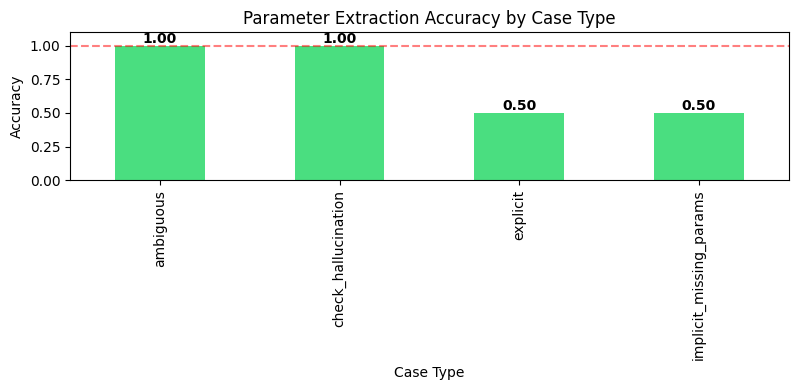

In [7]:

# Bar chart of accuracy grouped by case type
avg_acc_by_type = df_results.groupby('case_type')['param_accuracy'].mean()

plt.figure(figsize=(8, 4))
ax = avg_acc_by_type.plot(kind='bar', color='#4ade80')
plt.title('Parameter Extraction Accuracy by Case Type')
plt.ylabel('Accuracy')
plt.xlabel('Case Type')
plt.ylim(0, 1.1)
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5)

# Annotate
for i, v in enumerate(avg_acc_by_type):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



---
## 7. Trace Detail View
View the transformation pipeline for the first tested case.


In [8]:

first_case = df_results.iloc[0]
print("🔍 PIPELINE TRACE")
print(f"INPUT    → {first_case['input']}")
print(f"TOOL     → Expected: {first_case['expected_tool']} | Predicted: {first_case['predicted_tool']}")
print(f"PARAMS   → Expected: {first_case['expected_params']}")
print(f"           Predicted: {first_case['predicted_params']}")
print(f"ERRORS   → Missing: {first_case['missing_fields']} | Extra: {first_case['extra_fields']}")


🔍 PIPELINE TRACE
INPUT    → Make me 10 hard flashcards about cell division for biology.
TOOL     → Expected: flashcards | Predicted: flashcards
PARAMS   → Expected: {'topic': 'cell division', 'count': 10, 'difficulty': 'hard', 'subject': 'biology'}
           Predicted: {'topic': 'cell division', 'count': 10, 'difficulty': 'hard', 'subject': 'biology', 'include_examples': False, 'user_info': 'general'}
ERRORS   → Missing: ['topic', 'count', 'difficulty', 'subject'] | Extra: []
